# English Lemmatization and english resource

In [ ]:
pip install kagglehub[pandas-datasets]

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [ ]:
pip install lexical-diversity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.8/117.8 kB 3.0 MB/s eta 0:00:00


In [ ]:
import datasets
from datasets import load_dataset
import pandas as pd
from huggingface_hub import login
import pandas as pd

#url = "https://huggingface.co/datasets/RanaGaber/Egy_AMIYA/resolve/main/data/train-00000-of-00001.parquet"
#df = pd.read_parquet(url)
#ds = load_dataset("UBC-NLP/alexandria", split="train" , name = 'EG')
df = pd.read_csv('/content/Egy_MADAR.csv' , encoding = 'utf-8-sig')
df.head()


,Unnamed: 0,Text_DA,Country,Dataset,SentID,Text_EN
0,427,لو سمحت إبعت حد للشنط بتاعتى الساعة ستة ونص.,Egypt,madar,3856,Please send someone up for my bags at six thirty.
1,428,فين مكتب الممتلكات المفقودة؟,Egypt,madar,10114,Where is the lost property office?
2,429,هو أنا محتاج أى علاج مخصوص؟,Egypt,madar,10125,Do I need any special treatment?
3,430,الكنيسة ديه عمرها اد ايه؟,Egypt,madar,816,How old is that church?
4,431,احنا متأخرين شويه، بس ما تقلقش .,Egypt,madar,3813,"We are a little delayed, but don't worry."


In [ ]:
print(len(df))
df = df[df['Dataset'] == 'madar']
print(len(df))

14800
14800


In [ ]:
df.loc[0 , 'dialectal_conversation']

array([{'direction': 'male -> female', 'speaker': 'Wholesale Buyer', 'text': 'صباح الخير، عايز عشرة طن من الخرشوف الكويس للتصدير، بيقولوا ان احسن جودة في سوق العبور بتيجي من عندكم، صحيح؟', 'turn_order': 1},
       {'direction': 'female -> male', 'speaker': 'Wholesale Seller', 'text': 'صباح النور،سمعك مظبوط،الخرشوف بتاعي من أحسن اللي موجود في السوق، من أحسن الأنواع، معمول للتصدير.خليني أوريك عينة.', 'turn_order': 2},
       {'direction': 'male -> female', 'speaker': 'Wholesale Buyer', 'text': 'ممتاز، لو سمحتي وريني، عايزه بمقاس واحد ومافيهوش أي عيوب', 'turn_order': 3},
       {'direction': 'female -> male', 'speaker': 'Wholesale Seller', 'text': 'متخافش، هتنبسط جدا، سمعتي جاية من الحاجة الكويسة.', 'turn_order': 4}],
      dtype=object)

In [ ]:
df['Egyptian'] = df['dialectal_conversation'].apply(lambda turns: "\n".join([turn['text'] for turn in turns]))
df['English'] = df['english_conversation'].apply(lambda turns: "\n".join([turn['text'] for turn in turns]))

In [ ]:
import pandas as pd
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from lexical_diversity import lex_div as ld

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    tag = treebank_tag[0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "R": wordnet.ADV,
                "V": wordnet.VERB,
                "N": wordnet.NOUN}
    return tag_dict.get(tag, wordnet.NOUN)

def lemmatize_english_to_list(text):
    if pd.isna(text) or not isinstance(text, str):
        return []
    tokens = word_tokenize(text.lower())
    tokens = [w for w in tokens if w.isalpha()]
    if not tokens:
        return []
    tagged = nltk.pos_tag(tokens)
    lemmas = [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in tagged]
    return lemmas

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
def get_MTLD(toks):
  return ld.mtld(toks)
def get_TTR(toks):
  return ld.ttr(toks)

In [ ]:
df['English_lemma_list'] = df['Text_EN'].apply(lemmatize_english_to_list)

whole_english_corpus_tokens = [
    token
    for row_list in df['English_lemma_list']
    if isinstance(row_list, list)
    for token in row_list
]

df['mtld_per_row'] = df['English_lemma_list'].apply(get_MTLD)
mean_mtld = df['mtld_per_row'].mean()

df['ttr_per_row'] = df['English_lemma_list'].apply(get_TTR)
mean_row_ttr = df['ttr_per_row'].mean()

print(f"--- English Corpus-Wide Lexical Diversity ---")
print(f"Total English Tokens: {len(whole_english_corpus_tokens)}")
print(f"English Corpus MTLD:  {mean_mtld:.4f}")
print(f"Mean per-document TTR: {mean_row_ttr:.4f}")

--- English Corpus-Wide Lexical Diversity ---
Total English Tokens: 112418
English Corpus MTLD:  5.9560
Mean per-document TTR: 0.9774


# Arabic Lemmatization and lexical resource

In [ ]:
#pip install lexical-diversity
!pip install camel-tools
!camel_data -i light

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.3/122.3 kB 10.2 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=2851e4d8bdf191c590176d2a159ef9bbe67346b6da0206d2af451412772f561a
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting uninstall: scikit-learn
    Found exis

The following packages will be installed: 'morphology-db-lev-01', 'morphology-db-egy-r13', 'morphology-db-glf-01', 'morphology-db-msa-r13', 'dialectid-model26', 'morphology-db-msa-s31', 'disambig-mle-calima-egy-r13', 'disambig-mle-calima-msa-r13'
Extracting package 'morphology-db-lev-01': 100% 10.6M/10.6M [00:00<00:00, 685MB/s]
Extracting package 'morphology-db-egy-r13': 100% 67.3M/67.3M [00:00<00:00, 532MB/s]
Extracting package 'morphology-db-glf-01': 100% 7.98M/7.98M [00:00<00:00, 544MB/s]
Extracting package 'morphology-db-msa-r13': 100% 40.5M/40.5M [00:00<00:00, 528MB/s]
Extracting package 'dialectid-model26': 100% 275M/275M [00:01<00:00, 183MB/s]
Extracting package 'morphology-db-msa-s31': 100% 44.8M/44.8M [00:00<00:00, 199MB/s]
Extracting package 'disambig-mle-calima-egy-r13': 100% 27.2M/27.2M [00:00<00:00, 296MB/s]
Extracting package 'disambig-mle-calima-msa-r13': 100% 88.7M/88.7M [00:00<00:00, 206MB/s]


In [ ]:
import pandas as pd
from camel_tools.tokenizers.word import simple_word_tokenize
from camel_tools.disambig.mle import MLEDisambiguator
from lexical_diversity import lex_div as ld
from tqdm import tqdm

mle = MLEDisambiguator.pretrained()
def lemmatize_arabic_to_list(text):
    if pd.isna(text) or not isinstance(text, str):
        return []

    tokens = simple_word_tokenize(text)
    disambiguated = mle.disambiguate(tokens)

    lemmas = []
    for token, d in zip(tokens, disambiguated):
        if d.analyses:
            lemmas.append(d.analyses[0].analysis['lex'])
        else:
            lemmas.append(token)

    return lemmas

In [ ]:
df = pd.DataFrame(df)
df['dialectal_lemma_list'] = df['Text_DA'].apply(lemmatize_arabic_to_list)

whole_egy_corpus_tokens = [
    token
    for row_list in df['dialectal_lemma_list']
    if isinstance(row_list, list)
    for token in row_list
]
df['mtld_per_row_egy'] = df['dialectal_lemma_list'].apply(get_MTLD)
mean_mtld = df['mtld_per_row_egy'].mean()

df['ttr_per_row_egy'] = df['dialectal_lemma_list'].apply(get_TTR)
mean_row_ttr = df['ttr_per_row_egy'].mean()

print(f"--- Egyptian Corpus-Wide Lexical Diversity ---")
print(f"Total Egyptian Tokens: {len(whole_egy_corpus_tokens)}")
print(f"Egyptian Corpus MTLD:  {mean_mtld:.4f}")
print(f"Mean per-document TTR: {mean_row_ttr:.4f}")

--- Egyptian Corpus-Wide Lexical Diversity ---
Total Egyptian Tokens: 107683
Egyptian Corpus MTLD:  5.3602
Mean per-document TTR: 0.9763


In [ ]:
df_s = pd.DataFrame(columns = ['Dataset' , 'Language' , 'Total_tokens' , 'TTR' ,'MTLD'])
df_s = pd.DataFrame(columns=[
    'Dataset', 'Language', 'Total_tokens', 'TTR', 'MTLD'
])

df_s.loc[len(df_s)] = ['Madar', 'Egyptian', 107683, 0.9763, 5.3602]
df_s.loc[len(df_s)] = ['Madar',  'English', 112418, 0.9774, 5.956]

df_s.loc[len(df_s)] = ['Rewayat', 'Egyptian', 3415420,0.6065, 86.9016]
df_s.loc[len(df_s)] = ['Rewayat',  'English', 4486642, 0.4748, 57.1501]


df_s.loc[len(df_s)] = ['Alexandria', 'Egyptian', 50948, 0.7936, 73.0175]
df_s.loc[len(df_s)] = ['Alexandria',  'English', 55970, 0.7701, 70.4242]

df_s.loc[len(df_s)] = ['Fine Translations', 'Egyptian', 5736227,0.6253,85.9514]
df_s.loc[len(df_s)] = ['Fine Translations',  'English', 6955905, 0.5337,60.7914]


In [ ]:
df_s.to_csv('Lexical_resource.csv' , encoding = 'utf-8-sig')

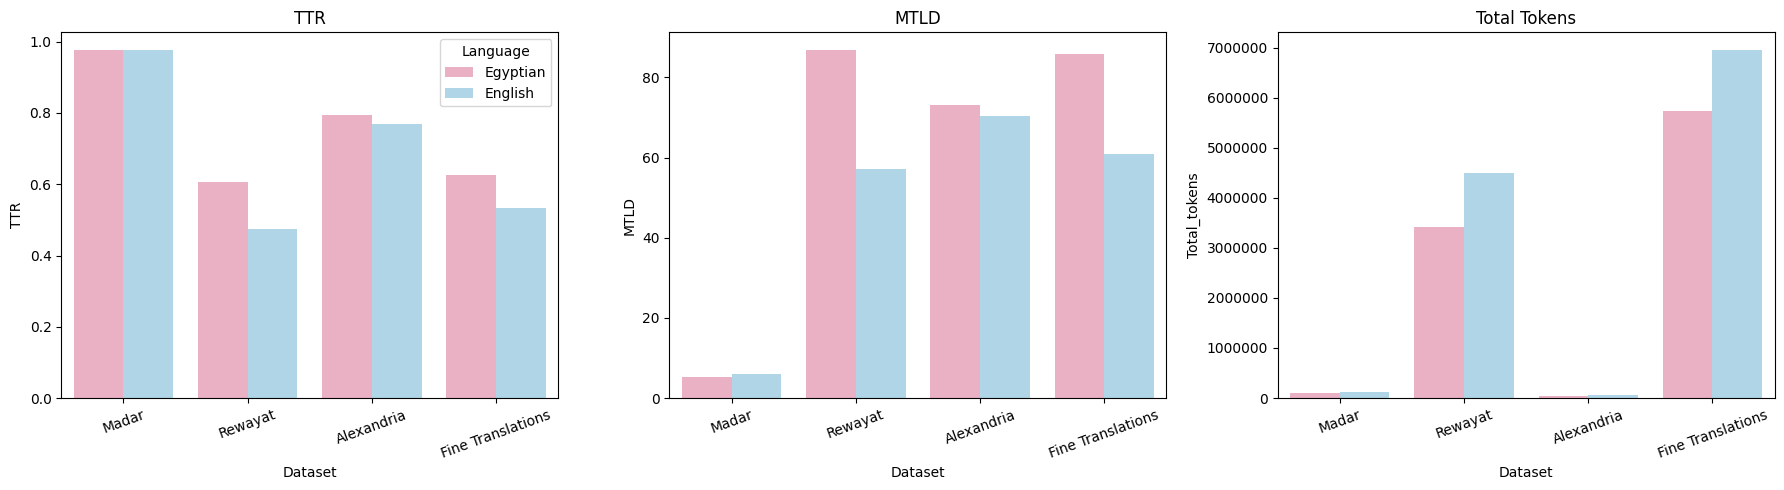

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = ["#F4A6C1", "#A7D8F0"]  
 
sns.barplot(
    data=df_s,
    x='Dataset',
    y='TTR',
    hue='Language',
    ax=axes[0],
    palette=palette
)
axes[0].set_title("TTR")
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(
    data=df_s,
    x='Dataset',
    y='MTLD',
    hue='Language',
    ax=axes[1],
    palette=palette
)
axes[1].set_title("MTLD")
axes[1].tick_params(axis='x', rotation=20)


sns.barplot(
    data=df_s,
    x='Dataset',
    y='Total_tokens',
    hue='Language',
    ax=axes[2],
    palette=palette
)
axes[2].set_title("Total Tokens")
axes[2].tick_params(axis='x', rotation=20)
axes[2].ticklabel_format(style='plain', axis='y')


axes[1].legend_.remove()
axes[2].legend_.remove()

plt.tight_layout()
plt.savefig('Lexical_resource.png' , dpi =300 )
plt.show()